In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.ma.core import cumsum

B = np.array(['B04', 'B11'])
depth = np.array(['29.53-29.56', '29.53-29.56'])

Q = np.array([0.12,0.26])


sigma_oc_akai = np.array([680,890])
sigma_oc_casa = np.array([600,800])

df = pd.DataFrame()
df['Borehole'] = B
df['Depth [m]'] = depth
df['$Q_(1600-3200)$'] = Q
df['sigma_oc_akai'] = sigma_oc_akai
df['sigma_oc_casa'] = sigma_oc_casa

print(df)


  Borehole    Depth [m]  $Q_(1600-3200)$  sigma_oc_akai  sigma_oc_casa
0      B04  29.53-29.56                0            680            600
1      B11  29.53-29.56                0            890            800


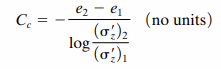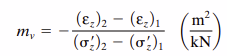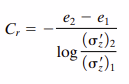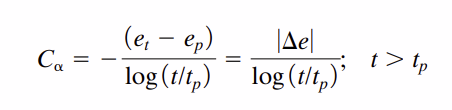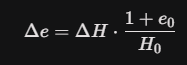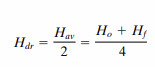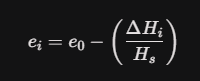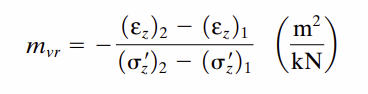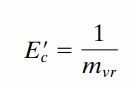

18 18 18 18
C_c  = 0.06524266778358777
C_r  = 0.010120807595756811
C_v  = 2.3e-07 m^2/s
C_alpha = 0.12 %/lct
m_v  = 0.15159999999999998 m^2/MN
m_vr = 0.013057142857142849 m^2/MN
E_prime_c = 76.58643326039392 MN/m^2
k_v  = 2e-11 m/s


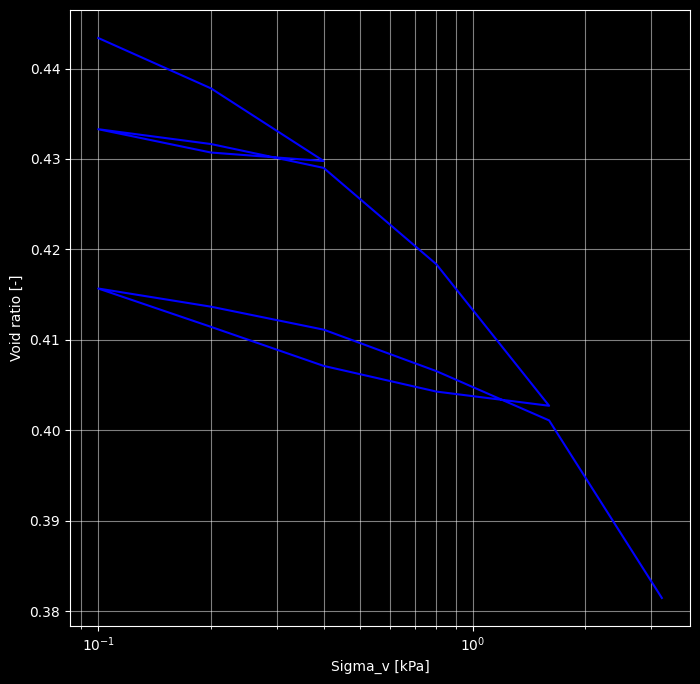

In [98]:
#english properties
e_0 = 0.454
H = 0.03
sigma_v = np.array([100,200,400,200,100,200,400,800,1600,800,400,200,100,200,400,800,1600,3200])*0.001
t_min = np.array([2910,1485,1374,301,1190,266,1134,1439,4412,176,134,1193,1397,1381,280,100,482,4273])
varep_t = np.array([1.062, 1.619, 2.423, 2.329, 2.071, 2.235, 2.499, 3.565, 5.130, 4.973, 4.689, 4.257,3.833, 4.034, 4.288, 4.747, 5.292, 7.256])
varep_t_deci = varep_t/100

C_alpha = np.array([0.01, 0.03, 0.06, 0.09, 0.08,0.12])

c_v = np.array([4.2e-7, 3.1e-7, 1.7e-7, 2e-7, 1.5e-7, 2.3e-7])
k_v = np.array([4.4e-10, 1.2e-10, 5.7e-11, 4.1e-11, 2.1e-11, 2.0e-11])

Delta_H = H * varep_t_deci
H_i = H-Delta_H

e_i = e_0 - (Delta_H/H)



print(len(varep_t),len(t_min),len(sigma_v), len(e_i))

e_1600_3200 = e_i[17]-e_i[16]
C_c = -(e_1600_3200/(np.log10(sigma_v[17]/sigma_v[16])))

e_100_1600_r = e_i[15]- e_i[12]
C_r = -(e_100_1600_r/(np.log10(sigma_v[15]/sigma_v[12])))


m_v  = (varep_t_deci[7]+varep_t_deci[6])/(sigma_v[7]-sigma_v[6])
m_vr = (varep_t_deci[15]-varep_t_deci[12])/(sigma_v[15]-sigma_v[12])

E_prime_c = 1/m_vr

gamma_w = 0.010



C_v = c_v[-1]
k_v = k_v[-1]
C_alpha = C_alpha[-1]

print(f"C_c  = {C_c}")
print(f"C_r  = {C_r}")
print(f"C_v  = {C_v} m^2/s")
print(f"C_alpha = {C_alpha} %/lct")
print(f"m_v  = {m_v} m^2/MN")
print(f"m_vr = {m_vr} m^2/MN")
print(f"E_prime_c = {E_prime_c} MN/m^2")
print(f"k_v  = {k_v} m/s")



fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(sigma_v,e_i,'b-',label='e_i')
ax.grid(visible=True, which="both", ls="-", alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Sigma_v [kPa]')
ax.set_ylabel('Void ratio [-]')
plt.show()